In [1]:
import pandas as pd

from sklearn import tree  # Arvore de decisão e plot tree
from sklearn.metrics import accuracy_score   # Acurácia
from sklearn.preprocessing import OrdinalEncoder  # Transformar coluna ordinária
from sklearn.model_selection import train_test_split  # Separar a parte de teste
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # Matriz de confusão
import matplotlib.pyplot as plt  # Plot na tabela

In [13]:
df = pd.read_csv('./class_german_credit.csv', sep=',')
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [36]:
df['Housing'].value_counts()

Housing
own     713
rent    179
free    108
Name: count, dtype: int64

In [27]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [14]:
df = df.dropna()

# Sex
df['Sex'] = (df['Sex'] == 'male').astype(int) # female -> 0; male -> 1;

# Housing
encoder = OrdinalEncoder(categories=[['free', 'rent', 'own']])
df['Housing'] = encoder.fit_transform(df[['Housing']])

# Saving Accounts
encoder = OrdinalEncoder(categories=[['little', 'moderate', 'quite rich', 'rich']])
df['Saving accounts'] = encoder.fit_transform(df[['Saving accounts']])

# Checking Account
encoder = OrdinalEncoder(categories=[['little', 'moderate', 'rich']])
df['Checking account'] = encoder.fit_transform(df[['Checking account']])

# Purpose
# df = pd.get_dummies(df, columns=['Purpose'], drop_first=True, dtype=int)
df = df.drop(columns=['Purpose'], axis=1)

# Risk
df['Risk'] = (df['Risk'] == 'good').astype(int) # bad -> 0; good -> 1;

df

/tmp/ipykernel_254166/1537352101.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = (df['Sex'] == 'male').astype(int) # female -> 0; male -> 1;
/tmp/ipykernel_254166/1537352101.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Housing'] = encoder.fit_transform(df[['Housing']])
/tmp/ipykernel_254166/1537352101.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
1,22,0,2,2.0,0.0,1.0,5951,48,0
3,45,1,2,0.0,0.0,0.0,7882,42,1
4,53,1,2,0.0,0.0,0.0,4870,24,0
7,35,1,3,1.0,0.0,1.0,6948,36,1
9,28,1,3,2.0,0.0,1.0,5234,30,0
...,...,...,...,...,...,...,...,...,...
989,48,1,1,2.0,0.0,1.0,1743,24,1
993,30,1,3,2.0,0.0,0.0,3959,36,1
996,40,1,3,2.0,0.0,0.0,3857,30,1
998,23,1,2,0.0,0.0,0.0,1845,45,0


In [15]:
df['Risk'].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [16]:
X = df.drop('Risk', axis=1)
y = df['Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify = y)

In [17]:
clf = tree.DecisionTreeClassifier(random_state=42)

# Treinamento
clf.fit(X_train, y_train)

# Teste
y_pred = clf.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f'A acurácia do modelo foi de {acuracia*100:.2f}%')

A acurácia do modelo foi de 51.43%


[Text(0.5219603825136612, 0.9642857142857143, 'x[7] <= 22.5\ngini = 0.494\nsamples = 417\nvalue = [185, 232]'),
 Text(0.2456967213114754, 0.8928571428571429, 'x[6] <= 1285.0\ngini = 0.447\nsamples = 243\nvalue = [82, 161]'),
 Text(0.38382855191256826, 0.9285714285714286, 'True  '),
 Text(0.15341530054644809, 0.8214285714285714, 'x[6] <= 1207.5\ngini = 0.493\nsamples = 91\nvalue = [40, 51]'),
 Text(0.12759562841530053, 0.75, 'x[0] <= 37.5\ngini = 0.475\nsamples = 80\nvalue = [31, 49]'),
 Text(0.10218579234972677, 0.6785714285714286, 'x[0] <= 29.5\ngini = 0.499\nsamples = 55\nvalue = [26.0, 29.0]'),
 Text(0.07759562841530054, 0.6071428571428571, 'x[6] <= 979.5\ngini = 0.463\nsamples = 44\nvalue = [16, 28]'),
 Text(0.0546448087431694, 0.5357142857142857, 'x[6] <= 599.5\ngini = 0.5\nsamples = 30\nvalue = [15, 15]'),
 Text(0.034972677595628415, 0.4642857142857143, 'x[4] <= 1.5\ngini = 0.346\nsamples = 9\nvalue = [2, 7]'),
 Text(0.02622950819672131, 0.39285714285714285, 'x[5] <= 0.5\ngini = 

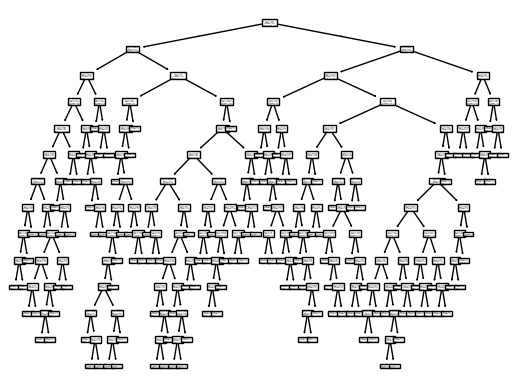

In [18]:
tree.plot_tree(clf)

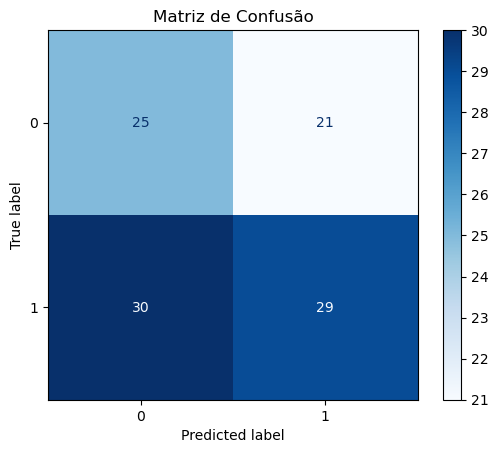

In [8]:
# Matriz de dispersão

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão')
plt.show()

In [19]:
importancia = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Importância das colunas:\n", importancia)

Importância das colunas:
 Credit amount       0.329693
Age                 0.226443
Duration            0.207044
Job                 0.069420
Checking account    0.066338
Saving accounts     0.058152
Housing             0.024728
Sex                 0.018182
dtype: float64
